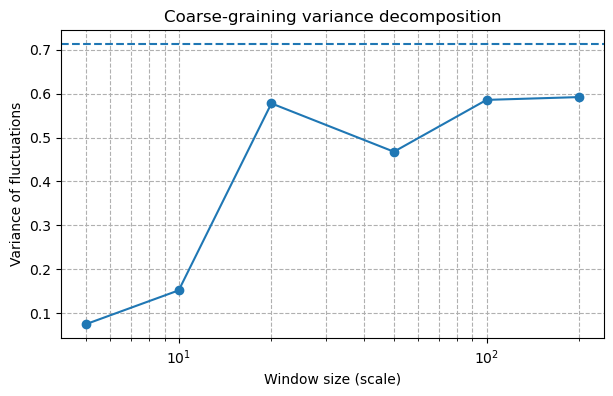

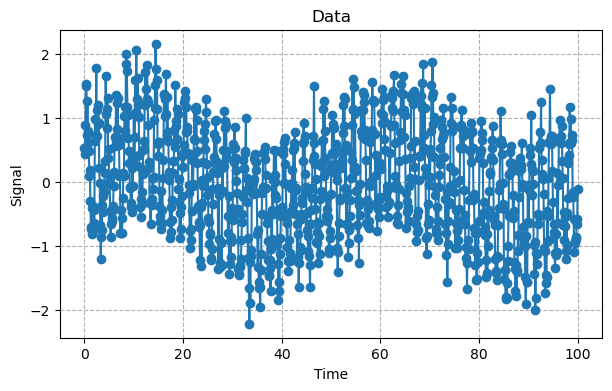

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Example signal: mix of two sinusoids + noise ---
np.random.seed(0)
t = np.linspace(0, 100, 1000)
signal = (np.sin(2*np.pi*t/2) +      # fast oscillation (period 10)
          0.5*np.sin(2*np.pi*t/50) +  # slow oscillation (period 50)
          0.3*np.random.randn(len(t)))  # noise

# --- Coarse-graining variance decomposition ---
def running_mean(x, window):
    """Compute running mean using convolution (same length)."""
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode='same')

# Choose window sizes (scales)
window_sizes = [5, 10, 20, 50, 100, 200]
var_by_scale = []
res = []

for w in window_sizes:
    smooth = running_mean(signal, w)
    residual = signal - smooth
    var_by_scale.append(np.var(residual))
    res.append(residual)

# --- Plot variance vs. scale ---
plt.figure(figsize=(7,4))
plt.plot(window_sizes, var_by_scale, marker='o')
plt.axhline(np.var(signal,ddof=1),ls='--')
plt.xscale('log')
plt.xlabel("Window size (scale)")
plt.ylabel("Variance of fluctuations")
plt.title("Coarse-graining variance decomposition")
plt.grid(True, which="both", ls="--")
plt.show()

# --- Plot variance vs. scale ---
plt.figure(figsize=(7,4))
plt.plot(t, signal, marker='o')
plt.xlabel("Time")
plt.ylabel("Signal")
plt.title("Data")
plt.grid(True, which="both", ls="--")
plt.show()




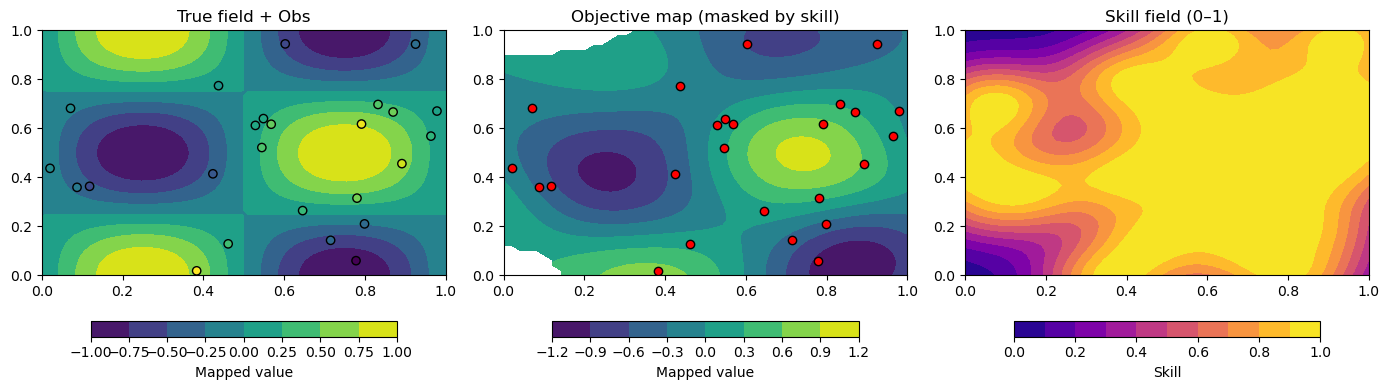

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# -----------------------------
# Parameters
# -----------------------------
sigma2 = 1      # Variance (amplitude squared)
L = 0.25           # Length scale (decorrelation scale)
noise_var = 0.01  # Observation error variance
skill_threshold = 0.2  # Minimum acceptable skill

# Gaussian covariance function
def cov_gaussian(r, sigma2=sigma2, L=L):
    return sigma2 * np.exp(-(r**2) / (L**2))

# -----------------------------
# Synthetic "observations"
# -----------------------------
np.random.seed(0)
n_obs = 25
obs_x = np.random.rand(n_obs)
obs_y = np.random.rand(n_obs)

# True underlying field (for testing)
def true_field(x, y):
    return np.sin(2*np.pi*x) * np.cos(2*np.pi*y)

obs_values = true_field(obs_x, obs_y) + 0.1*np.random.randn(n_obs)

# -----------------------------
# Build covariance matrix C_d
# -----------------------------
obs_pts = np.column_stack((obs_x, obs_y))
dists = np.linalg.norm(obs_pts[:, None, :] - obs_pts[None, :, :], axis=-1)
C_d = cov_gaussian(dists)
C_d += noise_var * np.eye(n_obs)  # nugget for stability

# -----------------------------
# Define grid for mapping
# -----------------------------
nx, ny = 50, 50
grid_x, grid_y = np.meshgrid(np.linspace(0,1,nx), np.linspace(0,1,ny))
grid_pts = np.column_stack((grid_x.ravel(), grid_y.ravel()))

# -----------------------------
# Perform objective mapping
# -----------------------------
mapped = np.zeros(len(grid_pts))
skill = np.zeros(len(grid_pts))

# Solve system once (reuse factorization)
for i, gp in enumerate(grid_pts):
    # Distances to obs
    r = np.linalg.norm(obs_pts - gp, axis=1)
    c = cov_gaussian(r)                # cross-covariance (n_obs,)

    # Solve for weights: C_d * w^T = c^T
    w = solve(C_d, c, assume_a='pos')  # assume positive-definite

    # Interpolated value
    mapped[i] = w @ obs_values

    # Error variance: sigma^2 - c^T w
    err_var = sigma2 - c @ w
    skill[i] = 1 - err_var/sigma2

# Reshape back to grid
mapped_field = mapped.reshape(ny, nx)
skill_field = skill.reshape(ny, nx)

# Mask points with skill < threshold
mapped_masked = np.ma.masked_where(skill_field < skill_threshold, mapped_field)

# -----------------------------
# Plot results
# -----------------------------
fig, ax = plt.subplots(1, 3, figsize=(14,4))

# True field
im0 = ax[0].contourf(grid_x, grid_y, true_field(grid_x, grid_y), cmap="viridis")
ax[0].scatter(obs_x, obs_y, c=obs_values, edgecolor='k', cmap="viridis")
ax[0].set_title("True field + Obs")

# Objective map (masked)
im1 = ax[1].contourf(grid_x, grid_y, mapped_masked, cmap="viridis")
ax[1].scatter(obs_x, obs_y, c='r', edgecolor='k')
ax[1].set_title("Objective map (masked by skill)")

# Skill field
im2 = ax[2].contourf(grid_x, grid_y, skill_field, cmap="plasma", levels=np.linspace(0,1,11))
ax[2].set_title("Skill field (0–1)")

plt.colorbar(im0, ax=ax[0], orientation="horizontal", fraction=0.05, label="Mapped value")
plt.colorbar(im1, ax=ax[1], orientation="horizontal", fraction=0.05, label="Mapped value")
plt.colorbar(im2, ax=ax[2], orientation="horizontal", fraction=0.05, label="Skill")
plt.tight_layout()
plt.show()


In [5]:
import numpy as np
from scipy.linalg import cho_factor, cho_solve

def objective_mapping(obs_xy, obs_values, grid_xy, sigma2=1.0, L=0.2, noise_var=0.01,
                      return_skill=False, skill_threshold=None):
    """
    Perform 2D objective mapping (optimal interpolation) using Gaussian covariance.

    Parameters
    ----------
    obs_xy : ndarray of shape (n_obs, 2)
        Observation coordinates (x, y).
    obs_values : ndarray of shape (n_obs,)
        Observation values.
    grid_xy : ndarray of shape (n_grid, 2)
        Grid coordinates where the field will be estimated.
    sigma2 : float
        Field variance.
    L : float
        Gaussian decorrelation length scale.
    noise_var : float
        Observation error variance (added to diagonal of covariance matrix).
    return_skill : bool, default=False
        If True, also return skill field (0–1).
    skill_threshold : float, optional
        If provided, mask out grid points with skill < threshold.

    Returns
    -------
    mapped : ndarray of shape (n_grid,)
        Objective map estimates at grid points (masked if skill_threshold set).
    skill : ndarray of shape (n_grid,), optional
        Skill (0–1) at each grid point, if return_skill=True.
    """
    # Gaussian covariance function
    def cov_gaussian(r):
        return sigma2 * np.exp(-(r**2) / (L**2))

    n_obs = obs_xy.shape[0]

    # -----------------------------
    # Build data-data covariance matrix (obs-obs)
    # -----------------------------
    dists_obs = np.linalg.norm(obs_xy[:, None, :] - obs_xy[None, :, :], axis=-1)
    C_d = cov_gaussian(dists_obs)
    C_d += noise_var * np.eye(n_obs)

    # Factorize once (Cholesky)
    c_factor = cho_factor(C_d, lower=True, check_finite=False)

    # -----------------------------
    # Build grid-data cross covariance (grid-obs)
    # -----------------------------
    dists_grid_obs = np.linalg.norm(grid_xy[:, None, :] - obs_xy[None, :, :], axis=-1)
    C_go = cov_gaussian(dists_grid_obs)   # shape (n_grid, n_obs)

    # -----------------------------
    # Solve for weights efficiently
    # -----------------------------
    W = cho_solve(c_factor, C_go.T, check_finite=False)  # shape (n_obs, n_grid)

    # -----------------------------
    # Interpolated values
    # -----------------------------
    mapped = obs_values @ W   # shape (n_grid,)

    # -----------------------------
    # Skill & masking
    # -----------------------------
    if return_skill or (skill_threshold is not None):
        err_var = sigma2 - np.sum(C_go * W.T, axis=1)
        skill = 1 - err_var / sigma2

        if skill_threshold is not None:
            mapped = np.ma.masked_where(skill < skill_threshold, mapped)

        if return_skill:
            return mapped, skill

    return mapped


In [10]:
# Grid setup
nx, ny = 50, 50
grid_x, grid_y = np.meshgrid(np.linspace(0,1,nx), np.linspace(0,1,ny))
grid_xy = np.column_stack((grid_x.ravel(), grid_y.ravel()))

# Observations
n_obs = 30
np.random.seed(0)
obs_xy = np.random.rand(n_obs, 2)
obs_values = np.sin(2*np.pi*obs_xy[:,0]) * np.cos(2*np.pi*obs_xy[:,1]) + 0.1*np.random.randn(n_obs)

# Run objective mapping with skill masking
mapped, skill = objective_mapping(obs_xy, obs_values, grid_xy, sigma2=1.0, L=0.2,
                                  noise_var=0.01, return_skill=True, skill_threshold=0.5)

mapped_field = mapped.reshape(ny, nx)
skill_field = skill.reshape(ny, nx)


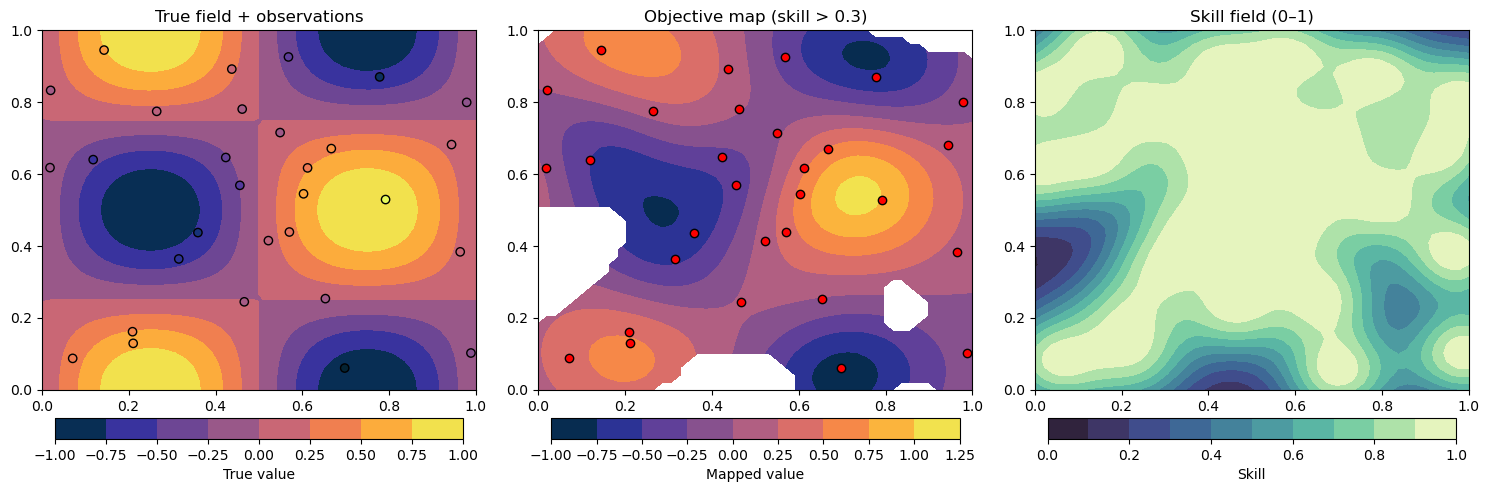

In [15]:
import cmocean.cm as cmo
# ======================================================
# Plotting
# ======================================================
fig, ax = plt.subplots(1, 3, figsize=(15,5))

# True field with obs
cf0 = ax[0].contourf(grid_x, grid_y, true_field(grid_x, grid_y), cmap=cmo.thermal)
ax[0].scatter(obs_xy[:,0], obs_xy[:,1], c=obs_values, edgecolor='k', cmap=cmo.thermal)
ax[0].set_title("True field + observations")
plt.colorbar(cf0, ax=ax[0], orientation="horizontal", fraction=0.05, pad=0.07, label="True value")

# Objective map (masked by skill)
cf1 = ax[1].contourf(grid_x, grid_y, mapped_field, cmap=cmo.thermal)
ax[1].scatter(obs_xy[:,0], obs_xy[:,1], c='r', edgecolor='k')
ax[1].set_title("Objective map (skill > 0.3)")
plt.colorbar(cf1, ax=ax[1], orientation="horizontal", fraction=0.05, pad=0.07,label="Mapped value")

# Skill field
cf2 = ax[2].contourf(grid_x, grid_y, skill_field, cmap=cmo.deep_r, levels=np.linspace(0,1,11))
ax[2].set_title("Skill field (0–1)")
plt.colorbar(cf2, ax=ax[2], orientation="horizontal", fraction=0.05, pad=0.07,label="Skill")

plt.tight_layout()
plt.show()

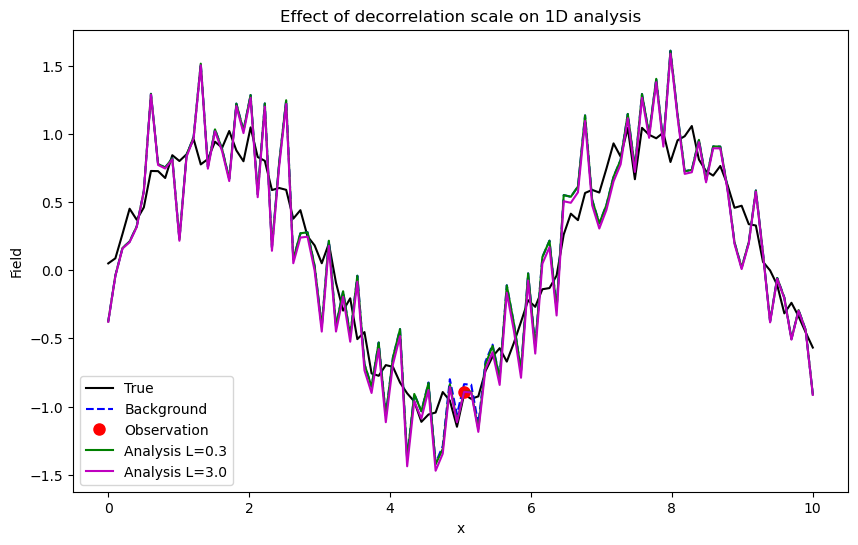

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# --- Set seed for reproducibility ---
np.random.seed(42)

# --- 1D domain ---
nx = 100
x = np.linspace(0, 10, nx)

# --- True field ---
true_field = np.sin(x) + 0.1 * np.random.randn(nx)

# --- Background (forecast) ---
background = true_field + 0.3 * np.random.randn(nx)

# --- Observation ---
obs_index = 50  # location of observation
obs_value = true_field[obs_index] + 0.05 * np.random.randn()  # small obs error

# --- Background error covariance ---
def compute_B(L, nx):
    """
    Create a Gaussian correlation background covariance matrix.
    """
    B = np.zeros((nx, nx))
    for i in range(nx):
        for j in range(nx):
            B[i, j] = np.exp(-((x[i]-x[j])**2)/(L**2))
    return B

# --- Kalman gain for a single observation ---
def analysis(B, background, obs_index, obs_value, R=0.01):
    """
    Simple 1D analysis for one observation
    """
    H = np.zeros(nx)
    H[obs_index] = 1
    K = B @ H / (H @ B @ H + R)  # Kalman gain
    xa = background + K * (obs_value - background[obs_index])
    return xa

# --- Try two decorrelation scales ---
L_small = 0.3
L_large = 3.0

B_small = compute_B(L_small, nx)
B_large = compute_B(L_large, nx)

analysis_small = analysis(B_small, background, obs_index, obs_value)
analysis_large = analysis(B_large, background, obs_index, obs_value)

# --- Plot ---
plt.figure(figsize=(10,6))
plt.plot(x, true_field, 'k-', label='True')
plt.plot(x, background, 'b--', label='Background')
plt.plot(x[obs_index], obs_value, 'ro', label='Observation', markersize=8)
plt.plot(x, analysis_small, 'g-', label=f'Analysis L={L_small}')
plt.plot(x, analysis_large, 'm-', label=f'Analysis L={L_large}')
plt.xlabel('x')
plt.ylabel('Field')
plt.legend()
plt.title('Effect of decorrelation scale on 1D analysis')
plt.show()


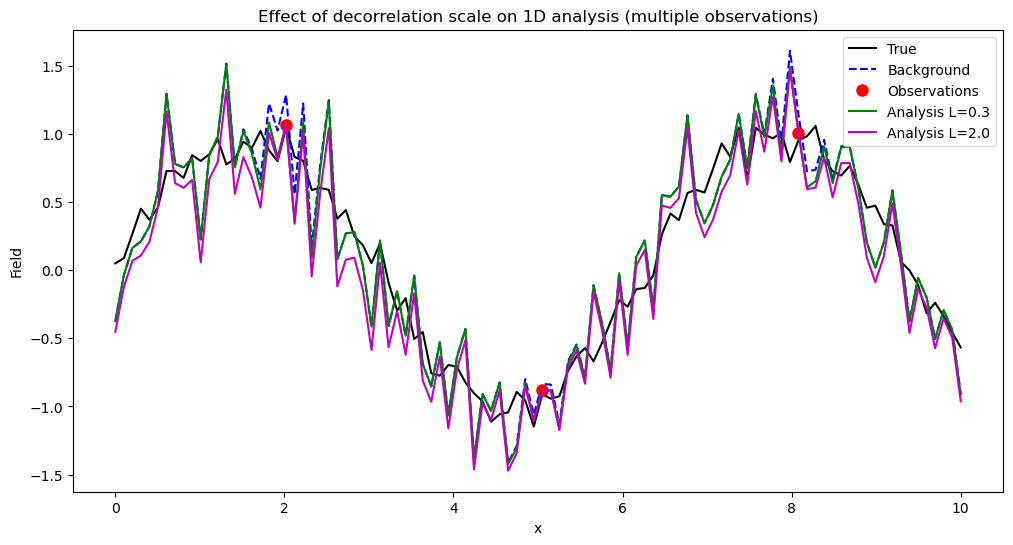

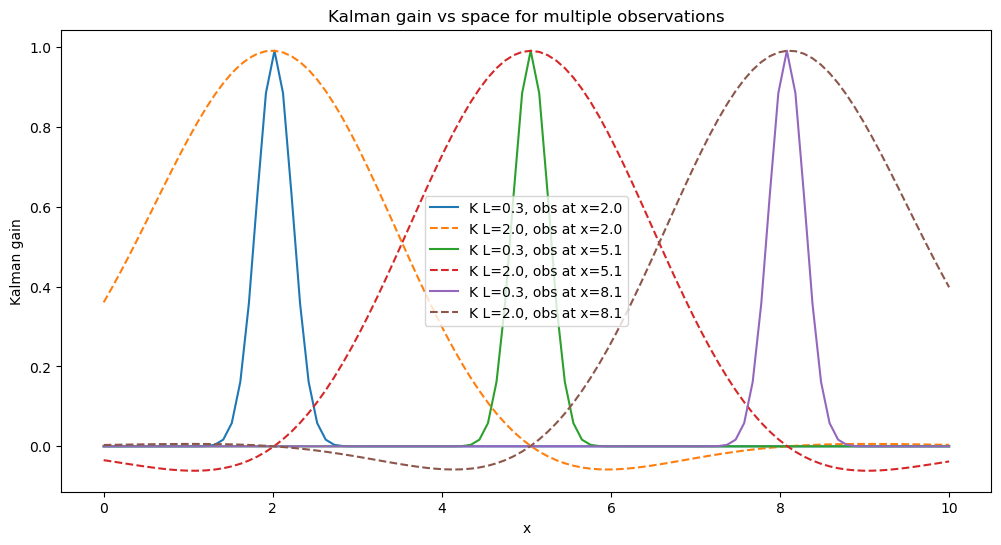

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# --- Set seed for reproducibility ---
np.random.seed(42)

# --- 1D domain ---
nx = 100
x = np.linspace(0, 10, nx)

# --- True field ---
true_field = np.sin(x) + 0.1 * np.random.randn(nx)

# --- Background (forecast) ---
background = true_field + 0.3 * np.random.randn(nx)

# --- Multiple observations ---
obs_indices = [20, 50, 80]  # locations of observations
obs_values = true_field[obs_indices] + 0.05 * np.random.randn(len(obs_indices))
R = 0.01 * np.eye(len(obs_indices))  # observation error covariance

# --- Background error covariance ---
def compute_B(L, nx):
    """Create a Gaussian correlation background covariance matrix."""
    dx = x[:, None] - x[None, :]
    B = np.exp(-(dx**2) / L**2)
    return B

# --- Observation operator for multiple observations ---
def compute_H(obs_indices, nx):
    """Create observation operator matrix H."""
    H = np.zeros((len(obs_indices), nx))
    for i, idx in enumerate(obs_indices):
        H[i, idx] = 1.0
    return H

# --- Kalman gain for multiple observations ---
def compute_K(B, H, R):
    """Compute Kalman gain matrix."""
    K = B @ H.T @ np.linalg.inv(H @ B @ H.T + R)
    return K

# --- Analysis update ---
def analysis(B, background, H, obs_values, R):
    K = compute_K(B, H, R)
    innovation = obs_values - H @ background
    xa = background + K @ innovation
    return xa, K

# --- Try two decorrelation scales ---
L_small = 0.3
L_large = 2.0

B_small = compute_B(L_small, nx)
B_large = compute_B(L_large, nx)
H = compute_H(obs_indices, nx)

analysis_small, K_small = analysis(B_small, background, H, obs_values, R)
analysis_large, K_large = analysis(B_large, background, H, obs_values, R)

# --- Plot the analysis ---
plt.figure(figsize=(12,6))
plt.plot(x, true_field, 'k-', label='True')
plt.plot(x, background, 'b--', label='Background')
plt.plot(x[obs_indices], obs_values, 'ro', label='Observations', markersize=8)
plt.plot(x, analysis_small, 'g-', label=f'Analysis L={L_small}')
plt.plot(x, analysis_large, 'm-', label=f'Analysis L={L_large}')
plt.xlabel('x')
plt.ylabel('Field')
plt.title('Effect of decorrelation scale on 1D analysis (multiple observations)')
plt.legend()
plt.show()

# --- Plot Kalman gain for each observation ---
plt.figure(figsize=(12,6))
for i, idx in enumerate(obs_indices):
    plt.plot(x, K_small[:, i], label=f'K L={L_small}, obs at x={x[idx]:.1f}')
    plt.plot(x, K_large[:, i], '--', label=f'K L={L_large}, obs at x={x[idx]:.1f}')
plt.xlabel('x')
plt.ylabel('Kalman gain')
plt.title('Kalman gain vs space for multiple observations')
plt.legend()
plt.show()


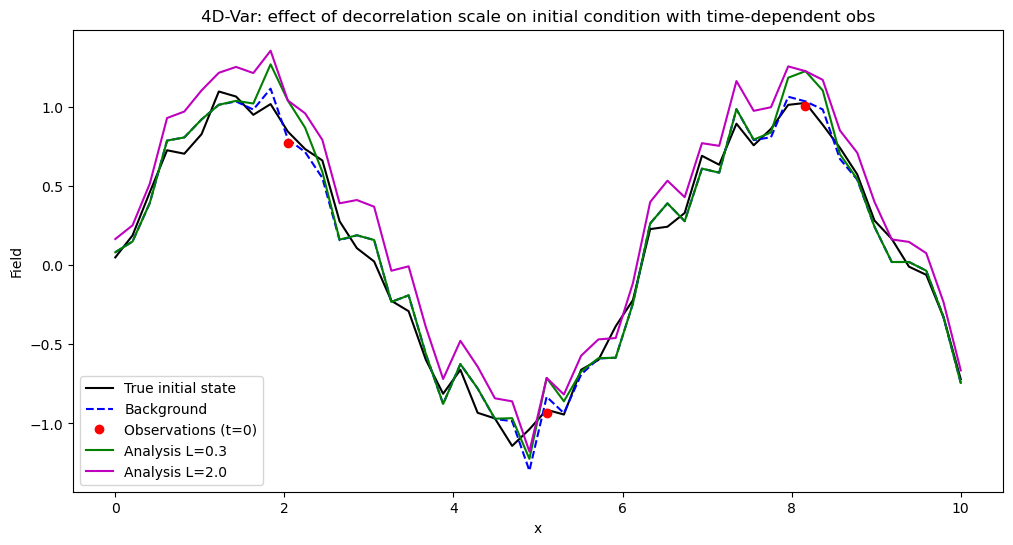

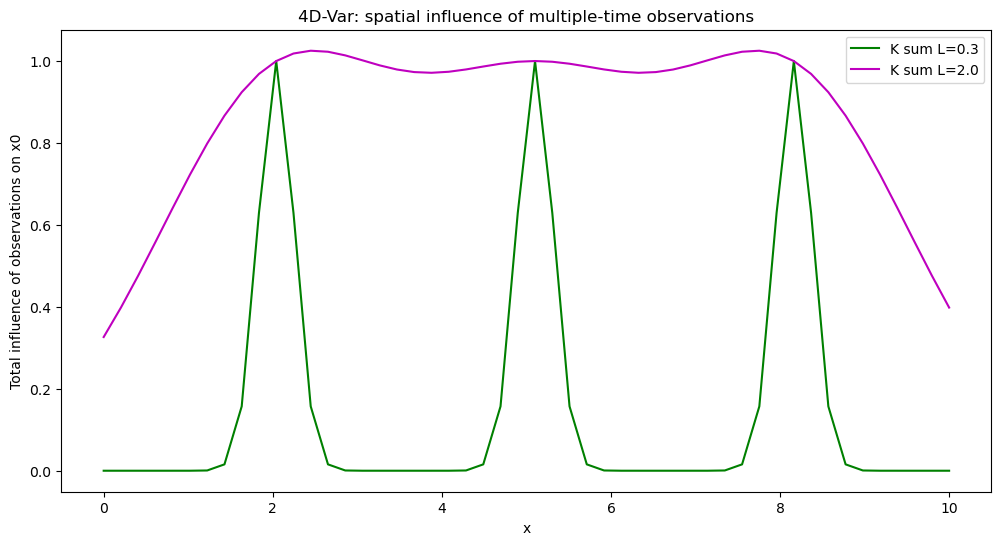

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seed for reproducibility ---
np.random.seed(42)

# --- 1D domain ---
nx = 50
x = np.linspace(0, 10, nx)

# --- True initial field ---
x0_true = np.sin(x) + 0.1 * np.random.randn(nx)

# --- Background (forecast) ---
x0b = x0_true + 0.1 * np.random.randn(nx)

# --- Linear model: simple advection x_t = x0 + t*dx ---
def model_forward(x0, t):
    return x0 + 0.1 * t  # simple linear evolution

nt = 5
times = np.arange(nt)

# --- Observations at different times ---
obs_indices = [10, 25, 40]  # spatial locations
obs_error_std = 0.05
obs_values = np.zeros((nt, len(obs_indices)))

for i, t in enumerate(times):
    obs_values[i] = model_forward(x0_true, t)[obs_indices] + obs_error_std * np.random.randn(len(obs_indices))
R = obs_error_std**2 * np.eye(len(obs_indices))  # observation error covariance

# --- Background error covariance ---
def compute_B(L, nx):
    dx = x[:, None] - x[None, :]
    B = np.exp(-(dx**2) / L**2)
    return B

# --- Observation operator for a single time step ---
def compute_H(nx, obs_indices):
    H = np.zeros((len(obs_indices), nx))
    for i, idx in enumerate(obs_indices):
        H[i, idx] = 1.0
    return H

# --- 4D-Var analysis for linear model with time dependence ---
def analysis_4dvar_linear_time(x0b, B, obs_values, obs_indices, R, times):
    nx = len(x0b)
    nt = len(times)
    n_obs = len(obs_indices)
    H = compute_H(nx, obs_indices)
    
    # Build combined H * M operator for all times
    HM_list = []
    y_list = []
    for i, t in enumerate(times):
        # Linear model: x_t = x0 + t*dx
        M = np.eye(nx)  # linear identity for mapping back to x0
        HM = H @ M
        HM_list.append(HM)
        y_list.append(obs_values[i])
    
    HM_combined = np.vstack(HM_list)
    y_combined = np.hstack(y_list)
    
    # Kalman-gain-like solution
    R_big = np.kron(np.eye(nt), R)
    K = B @ HM_combined.T @ np.linalg.inv(HM_combined @ B @ HM_combined.T + R_big)
    
    innovation = y_combined - HM_combined @ x0b
    x0a = x0b + K @ innovation
    return x0a, K

# --- Try two decorrelation scales ---
L_small = 0.3
L_large = 2.0
B_small = compute_B(L_small, nx)
B_large = compute_B(L_large, nx)

x0a_small, K_small = analysis_4dvar_linear_time(x0b, B_small, obs_values, obs_indices, R, times)
x0a_large, K_large = analysis_4dvar_linear_time(x0b, B_large, obs_values, obs_indices, R, times)

# --- Plot initial condition analysis ---
plt.figure(figsize=(12,6))
plt.plot(x, x0_true, 'k-', label='True initial state')
plt.plot(x, x0b, 'b--', label='Background')
plt.plot(x[obs_indices], obs_values[0], 'ro', label='Observations (t=0)')
plt.plot(x, x0a_small, 'g-', label=f'Analysis L={L_small}')
plt.plot(x, x0a_large, 'm-', label=f'Analysis L={L_large}')
plt.xlabel('x')
plt.ylabel('Field')
plt.title('4D-Var: effect of decorrelation scale on initial condition with time-dependent obs')
plt.legend()
plt.show()

# --- Plot total influence of observations (sum of Kalman gain) ---
plt.figure(figsize=(12,6))
plt.plot(x, K_small.sum(axis=1), 'g-', label=f'K sum L={L_small}')
plt.plot(x, K_large.sum(axis=1), 'm-', label=f'K sum L={L_large}')
plt.xlabel('x')
plt.ylabel('Total influence of observations on x0')
plt.title('4D-Var: spatial influence of multiple-time observations')
plt.legend()
plt.show()


Per-window variances at scale L=16:
[0.13286083 0.1611021  0.38692416 0.26741501 0.33050471 0.20996126
 0.09409893 0.16224804 0.39345592 0.27169268 0.24910698 0.28055533
 0.19847915 0.48636545 0.15812848 0.19732218 0.32676205 0.29675153
 0.33788018 0.1629623  0.2113241  0.2790386  0.49889781 0.10096414
 0.10782132 0.33750414 0.15807236 0.31945629 0.15854744 0.21026748
 0.31529635 0.31465241 0.21819899 0.25553945 0.31365277 0.17966163
 0.51471515 0.17726495 0.16340331 0.35330173 0.21542968 0.34868349
 0.15665508 0.14292192 0.18449524 0.27756575 0.25566234 0.31611617
 0.43232439 0.17112855 0.51775122 0.27758584 0.21569292 0.46029913
 0.19726581 0.35258436 0.23475968 0.20180116 0.37578386 0.47917592
 0.28131296 0.20659363 0.40128555 0.24888545 0.4038695  0.1785321
 0.1838505  0.36650217 0.21339738 0.2023869  0.21914793 0.22945044
 0.21369874 0.40310909 0.15538507 0.21614514 0.4983942  0.14319977
 0.37916639 0.23247846 0.21064378 0.26707022 0.26119095 0.30625795
 0.35585859 0.44468375 0.17

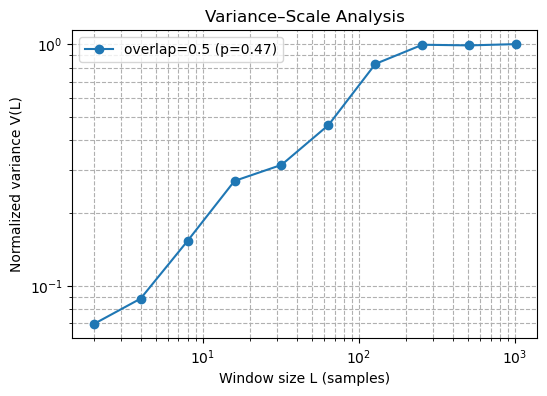

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def variance_scale_analysis(ts, scales=None, fit_range=None, overlap=0.0, return_windows=False):
    """
    Compute variance as a function of scale (Mahadevan et al. 2002 style)
    for a 1D time series, with option for overlapping windows. Patchness is computed
    from the slope of the V(L). 

    Parameters
    ----------
    ts : array_like
        1D time series.
    scales : list or array, optional
        Window sizes (number of points) to evaluate. If None, uses
        powers of 2 up to length of time series.
    fit_range : tuple (min_L, max_L), optional
        Range of scales to include in slope fit. If None, fits across all.
    overlap : float, default 0.0
        Fractional overlap between windows. 
        - 0.0 → no overlap
        - 0.5 → 50% overlap
        - 0.75 → 75% overlap
        Must satisfy 0 <= overlap < 1.
    return_windows : bool, default False
        If True, also return dictionary of raw per-window variances.

    Returns
    -------
    L : ndarray
        Window sizes (scale).
    V : ndarray
        Normalized variance at each scale.
    p : float
        Best-fit slope of log(V) vs log(L).
    intercept : float
        Intercept of the fitted line in log-log space.
    window_vars_dict : dict, optional
        Dictionary keyed by scale L with list of per-window variances (normalized).
        Only returned if return_windows=True.
    """

    #-----------------------------------#
    # STEP #1 - Compute V(L)
    #-----------------------------------#

    # Ensure input is a NumPy array and Total length of the time series
    ts = np.asarray(ts)              
    N = len(ts)                      

    # If no scales are provided, use powers of 2 up to the length of the time series
    if scales is None:
        max_power = int(np.floor(np.log2(N)))  # Maximum power of 2 less than N
        scales = [2**k for k in range(1, max_power+1)]  # e.g., [2,4,8,...]

    # Compute variance of full time series for normalization
    total_var = np.var(ts, ddof=1)   

    # Initialize list to store average variance per scale and dictionary to 
    # optionally store per-window variances
    V = []                           
    window_vars_dict = {}            

    # Loop over each window size / scale
    for L in scales:

        # Validate overlap input
        if not (0 <= overlap < 1):
            raise ValueError("overlap must be between 0 and 1 (fraction)")

        # Set step size between windows
        step = max(1, int(L * (1 - overlap)))  

        # Start indices for windows of length L
        starts = np.arange(0, N - L + 1, step)
        if len(starts) == 0:
            continue  # Skip if the window size is too large for the series

        # Store variance of each window
        window_vars = []  

        # Compute variance for each window
        for s in starts:

            # Extract segment/window
            segment = ts[s:s+L]                 

            # Compute variance
            window_vars.append(np.var(segment, ddof=1))  

        # Normalize by total variance and store per-window variances
        window_vars = np.array(window_vars) / total_var  
        window_vars_dict[L] = window_vars               

        # Average variance across all windows for this scale and store normalized 
        # average variance
        V_L = np.mean(window_vars)  
        V.append(V_L)               

    L = np.array(scales[:len(V)])  # Convert to NumPy array (ensure matching length)
    V = np.array(V)                # Convert variance list to NumPy array

    #-----------------------------------#
    # STEP #2 - Fit slope in log-log space 
    #-----------------------------------#

    # Log-transform for power-law relationship
    logL, logV = np.log10(L), np.log10(V)  

    # If a range for fitting is specified, only keep that subset
    if fit_range is not None:
        mask = (L >= fit_range[0]) & (L <= fit_range[1])
        logL, logV = logL[mask], logV[mask]

    # Linear fit in log-log space
    p, intercept = np.polyfit(logL, logV, 1)  

    # Return results, optionally including per-window variances
    if return_windows:
        return L, V, p, intercept, window_vars_dict
    else:
        return L, V, p, intercept


# ---------------- Example Usage ---------------- #
np.random.seed(0)
t = np.linspace(0, 100, 1024)  # Time vector
signal = np.sin(2*np.pi*0.05*t) + 0.5*np.sin(2*np.pi*0.5*t) + 0.2*np.random.randn(len(t))
# Construct a signal with two sine components plus noise

# Compute variance-scale analysis with 50% overlapping windows
L, V, p, _, window_vars = variance_scale_analysis(signal, overlap=0.5, return_windows=True)

# Example: Inspect per-window variances at a mid-size scale
example_scale = L[3]  # pick the 4th scale
print(f"Per-window variances at scale L={example_scale}:")
print(window_vars[example_scale])

# Plot normalized variance as a function of scale
plt.figure(figsize=(6,4))
plt.loglog(L, V, 'o-', label=f"overlap=0.5 (p={p:.2f})")
plt.xlabel("Window size L (samples)")
plt.ylabel("Normalized variance V(L)")
plt.title("Variance–Scale Analysis")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


In [ ]:
import numpy as np

def compute_potential_energy_time_series(rho, z, rho_ref="time-mean", g=9.81, rho0=1025.0,
                                         dz_is_positive_up=False, clip_unstable=True):
    """
    Compute column-integrated potential energy anomaly as a function of time.

    The method follows the quadratic small-displacement form used in oceanography:

        PE(t) = (1/2) ∫ g * [ (rho(t,z) - rho_r(z))^2 / (rho0 * N^2(z)) ] dz,

    where N^2(z) = -(g / rho0) * d rho_r / dz (for z positive upward). If your z increases downward,
    set `dz_is_positive_up=False` (default), and the routine will internally flip the sign to ensure
    a consistent N^2 computation.

    Parameters
    ----------
    rho : ndarray, shape (T, Z)
        Time-varying in-situ or potential density profile (kg m^-3) vs. depth/height levels z.
        The first dimension is time, the second is vertical level.
    z : ndarray, shape (Z,)
        Vertical coordinate (meters). Can be positive downward (common in oceanography) or
        positive upward. Use `dz_is_positive_up` to indicate orientation.
    rho_ref : {'time-mean', ndarray}, optional
        Reference density profile ρ_r(z). If 'time-mean', use time mean of `rho` (default).
        If ndarray, must have shape (Z,) and will be used directly.
    g : float, optional
        Gravitational acceleration (m s^-2). Default is 9.81.
    rho0 : float, optional
        Constant reference density (kg m^-3). Default is 1025.
    dz_is_positive_up : bool, optional
        If True, `z` is positive upward. If False (default), `z` is positive downward.
        The function accounts for this when computing N^2.
    clip_unstable : bool, optional
        If True (default), any non-positive N^2 values are clipped to a small positive floor
        to avoid division-by-zero or negative stratification issues. If False, such levels
        will be set to NaN and excluded from the integral.

    Returns
    -------
    PE : ndarray, shape (T,)
        Column-integrated potential energy anomaly time series (J m^-2).
    N2 : ndarray, shape (Z,)
        Buoyancy frequency squared from the reference profile (s^-2).
    rho_r : ndarray, shape (Z,)
        Reference profile used (kg m^-3).
    """
    rho = np.asarray(rho)
    z = np.asarray(z)
    assert rho.ndim == 2, "rho must be (T, Z)"
    T, Z = rho.shape
    assert z.shape == (Z,), "z must have shape (Z,)"

    # Reference profile
    if isinstance(rho_ref, str):
        if rho_ref.lower() == "time-mean":
            rho_r = np.nanmean(rho, axis=0)
        else:
            raise ValueError("rho_ref must be 'time-mean' or a 1D ndarray of shape (Z,)")
    else:
        rho_r = np.asarray(rho_ref)
        assert rho_r.shape == (Z,), "rho_ref array must have shape (Z,)"

    # Compute drho_r/dz
    drho_dz = np.gradient(rho_r, z)
    if dz_is_positive_up:
        N2 = -(g / rho0) * drho_dz
    else:
        N2 = (g / rho0) * drho_dz

    # Handle unstable/zero stratification
    if clip_unstable:
        N2_floor = np.nanpercentile(N2[N2 > 0], 0.5) if np.any(N2 > 0) else 1e-8
        N2 = np.where(N2 > N2_floor, N2, N2_floor)
        weight = np.ones_like(N2, dtype=float)
    else:
        weight = np.where(N2 > 0, 1.0, np.nan)

    # Density anomaly
    drho = rho - rho_r[None, :]

    # Integrand
    integrand = 0.5 * g * (drho ** 2) / (rho0 * N2[None, :])
    integrand_w = integrand * weight[None, :]

    # Sort z if not monotonic
    sort_idx = np.argsort(z)
    z_sorted = z[sort_idx]
    integrand_sorted = integrand_w[:, sort_idx]

    # Integrate with trapezoidal rule
    PE = np.trapz(integrand_sorted, z_sorted, axis=1)

    return PE, N2, rho_r


/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_30011/3644390537.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  PE = np.trapz(integrand_sorted, z_sorted, axis=1)


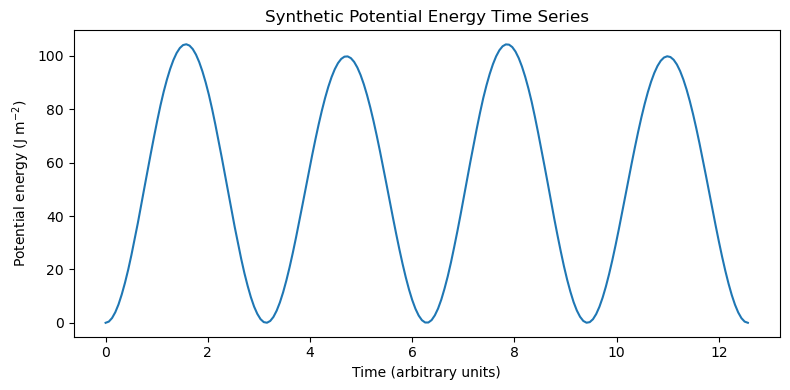

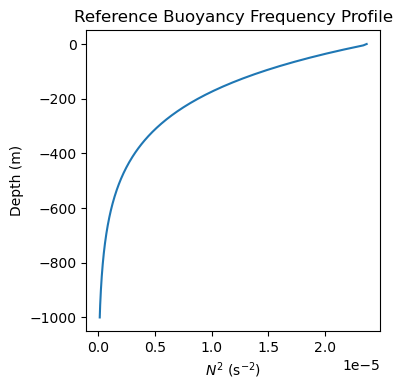

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Synthetic dataset ---
Z = 200              # vertical levels
H = 1000.0           # depth (m)
z = np.linspace(0, H, Z)  # depth positive downward
rho0 = 1025.0        # reference density (kg/m^3)

# Reference density profile: stable exponential stratification
rho_r_demo = rho0 + 0.5 * (1 - np.exp(-z / 200.0))

# Time dimension
T = 200
t = np.linspace(0, 4*np.pi, T)  # arbitrary time (radians)

# Internal-wave-like vertical displacement
eta_amp = 30.0  # meters
eta = eta_amp * np.sin(t)

# Vertical mode structure (first baroclinic mode shape, decaying with depth)
mode_shape = np.exp(-z / 400.0)

# Construct time-varying density field
rho_tz = np.empty((T, Z))
for i in range(T):
    z_shift = z - eta[i] * mode_shape
    rho_tz[i] = np.interp(z_shift, z, rho_r_demo, left=rho_r_demo[0], right=rho_r_demo[-1])

# --- Compute potential energy time series ---
PE, N2, rho_r = compute_potential_energy_time_series(
    rho=rho_tz,
    z=z,
    rho_ref=rho_r_demo,     # use our known reference profile
    g=9.81,
    rho0=rho0,
    dz_is_positive_up=False,
    clip_unstable=True
)

# --- Plot results ---
plt.figure(figsize=(8,4))
plt.plot(t, PE)
plt.xlabel("Time (arbitrary units)")
plt.ylabel("Potential energy (J m$^{-2}$)")
plt.title("Synthetic Potential Energy Time Series")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,4))
plt.plot(N2, -z)  # flip z for plotting (depth down)
plt.xlabel("$N^2$ (s$^{-2}$)")
plt.ylabel("Depth (m)")
plt.title("Reference Buoyancy Frequency Profile")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, correlate
import pywt

# -----------------------------
# Generate synthetic multiscale time series
# -----------------------------
np.random.seed(0)
n = 2**12  # length of signal
t = np.arange(n)

# Combine multiple scales:
signal = (
    np.sin(2 * np.pi * t / 512)       # low frequency (large scale)
    + 0.5 * np.sin(2 * np.pi * t / 64)  # mid frequency
    + 0.2 * np.random.randn(n)        # white noise (small scales)
)

# -----------------------------
# Power Spectrum (Welch’s method)
# -----------------------------
freqs, psd = welch(signal, nperseg=512)

# -----------------------------
# Autocorrelation Function (ACF)
# -----------------------------
signal_demean = signal - np.mean(signal)
acf_full = correlate(signal_demean, signal_demean, mode="full")
acf = acf_full[n-1:] / acf_full[n-1]  # normalize
lags = np.arange(len(acf))

# Integral decorrelation scale (up to first zero crossing)
zero_crossings = np.where(acf < 0)[0]
if len(zero_crossings) > 0:
    cutoff = zero_crossings[0]
else:
    cutoff = len(acf)
integral_scale = np.trapz(acf[:cutoff], dx=1)

# -----------------------------
# Wavelet variance decomposition
# -----------------------------
wavelet = 'db4'
coeffs = pywt.wavedec(signal, wavelet, level=6)
wavelet_vars = [np.var(c) for c in coeffs[1:]]  # skip approximation coeffs
scales = [2**i for i in range(1, len(wavelet_vars)+1)]

# -----------------------------
# Plotting
# -----------------------------
fig, axs = plt.subplots(4, 1, figsize=(8, 12))

# Time series
axs[0].plot(t, signal, lw=1)
axs[0].set_title("Synthetic Multiscale Signal (time series)")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")

# Spectrum
axs[1].loglog(freqs, psd)
axs[1].set_title("Power Spectrum (Welch)")
axs[1].set_xlabel("Frequency")
axs[1].set_ylabel("PSD")

# ACF
axs[2].plot(lags[:200], acf[:200])
axs[2].axhline(0, color="k", lw=0.8)
axs[2].set_title(f"Autocorrelation Function (Integral scale ≈ {integral_scale:.1f})")
axs[2].set_xlabel("Lag")
axs[2].set_ylabel("ACF")

# Wavelet variance
axs[3].bar(scales, wavelet_vars, width=1.5)
axs[3].set_xscale("log", base=2)
axs[3].set_title("Wavelet Variance by Scale")
axs[3].set_xlabel("Scale (dyadic)")
axs[3].set_ylabel("Variance")

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'pywt'